### EDA of the EuroSAT RGB imagery
The dataset contains all the RGB and Bands images from Sentinel-2. This notebook explores the RGB images, each of which is 64x64 pixels, containing 3 channels.

In [1]:
from eurosat import data
import matplotlib.pyplot as plt
import pandas as pd
import torch as t

/home/auste/dev/EuroSat/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Loading Data

The below code downloads the data from Kaggle (in case any errors, refer to README.md for instructions) and creates the train/validation/test split sets, based on information provided through Kaggle (label map, explicit splits). Our data is converted to a tensor and normalized through loading, as can be observed in the indexed image. Indexing returns not only the tensor image, but also the associated label.

In [2]:
path = data.download_data()
train_data, val_data, test_data = data.load_data_rgb(path)
train_data[0]

Data at /home/auste/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6.


(tensor([[[0.5882, 0.5804, 0.5647,  ..., 0.2157, 0.2196, 0.2157],
          [0.5922, 0.5804, 0.5647,  ..., 0.2157, 0.2196, 0.2157],
          [0.5569, 0.5529, 0.5725,  ..., 0.2235, 0.2196, 0.2196],
          ...,
          [0.2588, 0.2627, 0.2667,  ..., 0.2588, 0.2902, 0.2980],
          [0.2588, 0.2588, 0.2667,  ..., 0.2471, 0.2824, 0.2784],
          [0.2588, 0.2588, 0.2667,  ..., 0.2431, 0.2745, 0.2784]],
 
         [[0.4941, 0.4980, 0.4824,  ..., 0.3059, 0.3137, 0.3098],
          [0.4980, 0.4980, 0.4824,  ..., 0.3059, 0.3137, 0.3098],
          [0.4706, 0.4706, 0.4902,  ..., 0.3020, 0.3098, 0.3098],
          ...,
          [0.3412, 0.3451, 0.3490,  ..., 0.3412, 0.3608, 0.3686],
          [0.3529, 0.3529, 0.3490,  ..., 0.3412, 0.3569, 0.3529],
          [0.3529, 0.3529, 0.3490,  ..., 0.3373, 0.3569, 0.3529]],
 
         [[0.4863, 0.4863, 0.4784,  ..., 0.3294, 0.3294, 0.3255],
          [0.4980, 0.4941, 0.4784,  ..., 0.3294, 0.3294, 0.3255],
          [0.4784, 0.4667, 0.4863,  ...,

##### Analyzing Data

Our dataset contains 18900 samples for the training set, 5400 for validation and 2700 for testing.

In [3]:
len(train_data), len(val_data), len(test_data)

(18900, 5400, 2700)

We use .permute in order to change the order of the dimensions and channels around, since matplotlib expects the channels as the last dimension. Additionally, using the index of the image, we can check its information in the associated csv file, which, again, notes that the class is 5, which corresponds to Pasture.

Filename     Pasture/Pasture_1887.jpg
Label                               5
ClassName                     Pasture
Name: 0, dtype: object

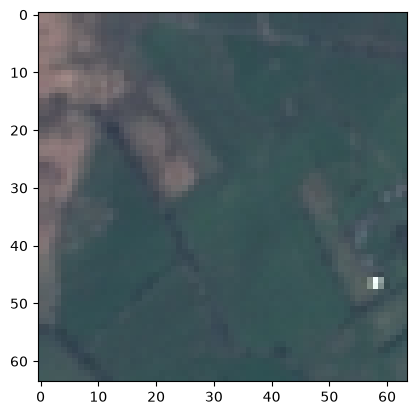

In [4]:
plt.imshow(train_data[0][0].permute(1, 2, 0))
train_data.df.iloc[0]

The following block displays a sample of each class in our training dataset, which we have 10 of. This gives us a general idea of how the images look like and their similarities: For instance, I suspect that determining the differences between a highway, industrial and residential zones may be more difficult for a simplier model, depending on the images complexity.

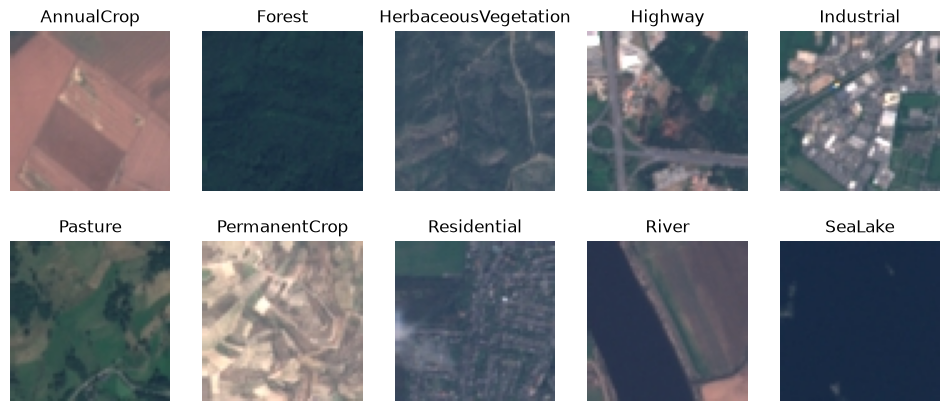

In [6]:
label_map = pd.Series(train_data.label_map)

figure = plt.figure(figsize=(12,5))
cols, rows = 5, 2

choices = train_data.df.groupby('Label').sample(1, random_state=42).index

for i, idx in enumerate(choices, start=1):
    img, label = train_data[idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[label])
    plt.axis('off')
    plt.imshow(img.permute(1, 2, 0))

plt.show()